# Classifying and Tagging Maze Hexes

This tutorial covers functions for classifying open hexes into structural regions and tagging them with descriptive labels. These go beyond `divide_into_thirds` by providing finer region information, including explicit handling of choice loops between port regions, port-perspective thirds, and per-hex tag sets combining structural and path-role information.

## Useful functions
All functions below accept `maze` in any valid format.

### `classify_hexes_by_region`: classify open hexes into 9 named structural regions

Returns a dict with 9 keys:
- `'to_1'`, `'to_2'`, `'to_3'`: hexes structurally between a port and its choice point
- `'loop_12'`, `'loop_13'`, `'loop_23'`: hexes on the choice loop between two ports' choice points (empty for mazes with no loops)
- `'choice_point_1'`, `'choice_point_2'`, `'choice_point_3'`: the critical choice point(s) for each port

### `divide_into_thirds_from_port`: like `divide_into_thirds`, but resolves loop ambiguity from a start port's perspective

Parameters: `maze`, `start_port` (1/2/3 or A/B/C)

Returns `[{port 1 hexes}, {port 2 hexes}, {port 3 hexes}]`. Loop segments between the start port's choice point and another port's choice point are assigned to that other port's third. The loop between the two non-start ports is left unassigned (white). For mazes with no loops, identical to `divide_into_thirds`.

### `tag_hexes`: tag each open hex with a set of descriptive string labels

Returns `dict[int, set[str]]` — each open hex maps to a set of tags. A hex can carry multiple tags simultaneously:
- `'to_port_1'`, `'to_port_2'`, `'to_port_3'`: which port's third the hex belongs to (from `divide_into_thirds`)
- `'choice_loop'`: hex is part of a choice loop (not in any port's third)
- `'optimal'`, `'non_optimal'`, `'dead_end'`: path role classification
- `'choice_point'`: critical choice point from any port
- `'choice_point_1'`, `'choice_point_2'`, `'choice_point_3'`: critical choice point from a specific port

### `get_junction_left_right_map`: classify exits at 3-way junctions as 'left' or 'right'

Parameters: `maze`, `hex_centroids` (optional)

Returns `dict` mapping `(junction_hex, entry_hex)` → `{'left': exit_hex, 'right': exit_hex}`. Uses the 2D cross product of the rat's heading vector (entry → junction) and exit vector (junction → exit) to determine turn direction.

Note: `get_junction_left_right_map` is not yet exported from the top-level `src.hexmaze` package — import it from `src.hexmaze.core` directly.

# 1. classify_hexes_by_region

Simple maze — non-empty regions:
  to_1: [1, 4, 5, 6, 8, 11, 14, 18]
  to_2: [2, 32, 37, 38, 47, 49]
  to_3: [3, 33, 34, 39, 43, 48]
  loop_12: [21, 25, 26]
  loop_13: [9, 12, 13, 15, 16, 19, 23, 24]
  loop_23: [35, 36, 40, 41, 45, 46]
  choice_point_1: [17]
  choice_point_2: [31]
  choice_point_3: [29]


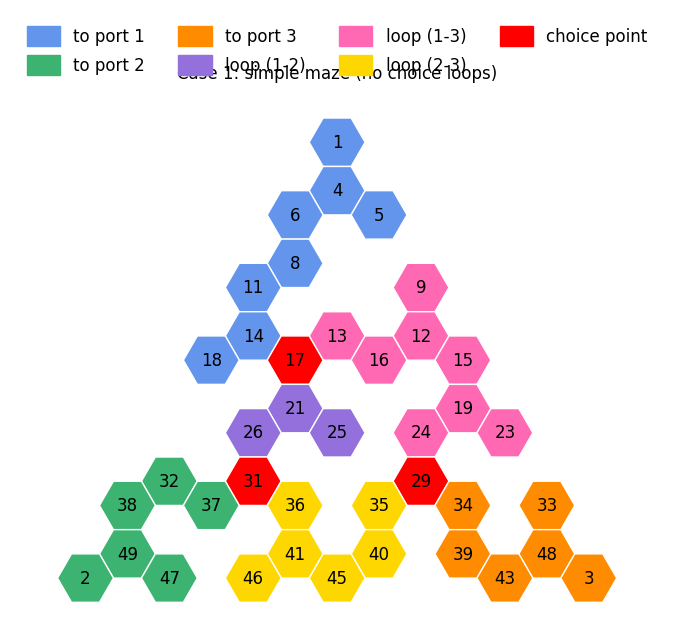

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import sys
sys.path.append("..")  # Use sys to add the parent directory (where src/hexmaze lives) to the path

from src.hexmaze import (
    plot_hex_maze,
    classify_hexes_by_region,
    divide_into_thirds_from_port,
    tag_hexes,
    get_all_choice_points,
)

# Load the barrier sequence database
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')

# Shared color scheme for the 9 regions
REGION_COLORS = {
    "to_1":         "cornflowerblue",
    "to_2":         "mediumseagreen",
    "to_3":         "darkorange",
    "loop_12":      "mediumpurple",
    "loop_13":      "hotpink",
    "loop_23":      "gold",
    "choice_point": "red",
}

REGION_LEGEND = [
    mpatches.Patch(color="cornflowerblue", label="to port 1"),
    mpatches.Patch(color="mediumseagreen", label="to port 2"),
    mpatches.Patch(color="darkorange",     label="to port 3"),
    mpatches.Patch(color="mediumpurple",   label="loop (1-2)"),
    mpatches.Patch(color="hotpink",        label="loop (1-3)"),
    mpatches.Patch(color="gold",           label="loop (2-3)"),
    mpatches.Patch(color="red",            label="choice point"),
]

def region_highlights(regions):
    """Return (highlight_sets, colors) from classify_hexes_by_region output."""
    keys = ["to_1", "to_2", "to_3", "loop_12", "loop_13", "loop_23"]
    all_cps = regions["choice_point_1"] | regions["choice_point_2"] | regions["choice_point_3"]
    sets   = [regions[k] for k in keys] + [all_cps]
    colors = [REGION_COLORS[k] for k in keys] + [REGION_COLORS["choice_point"]]
    return sets, colors


# ── Case 1: simple maze with no choice loops ──────────────────────────────────
maze_simple = barrier_sequence_database.iloc[7]['barrier_sequence'][0]
regions_simple = classify_hexes_by_region(maze_simple)

print("Simple maze — non-empty regions:")
for k, v in regions_simple.items():
    if v:
        print(f"  {k}: {sorted(v)}")

sets, colors = region_highlights(regions_simple)
fig, ax = plt.subplots(figsize=(8, 6))
plot_hex_maze(maze_simple, highlight_hexes=sets, highlight_colors=colors,
              show_barriers=False, show_hex_labels=True, ax=ax)
ax.set_title("Case 1: simple maze (no choice loops)")
fig.legend(handles=REGION_LEGEND, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08),
           fontsize=12, handlelength=2, handleheight=1.5, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()

Loop maze — non-empty regions:
  to_1: [1, 4, 5, 6, 7, 9, 12]
  to_2: [2, 32, 38, 41, 42, 46, 47, 49]
  to_3: [3, 19, 23, 28, 33, 39, 43, 44, 48]
  loop_12: [11, 13, 14, 17, 18, 21, 22, 26, 31]
  choice_point_1: [16, 24]
  choice_point_2: [24, 36]
  choice_point_3: [24]


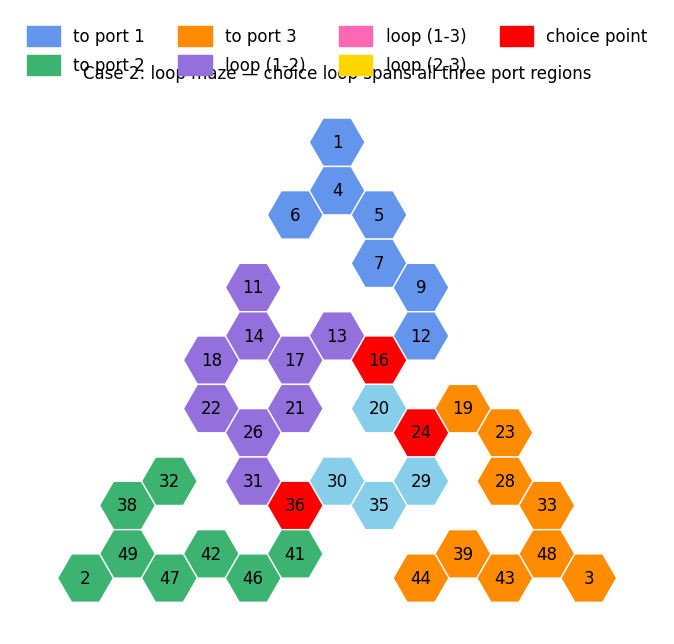

In [2]:
# ── Case 2: maze with a choice loop ──────────────────────────────────────────
# This maze has a loop connecting all three port regions.
# The loop segments are assigned to loop_12, loop_13, or loop_23
# based on which pair of choice points they sit between.
maze_loop = '8,10,15,25,27,34,37,40,45'
regions_loop = classify_hexes_by_region(maze_loop)

print("Loop maze — non-empty regions:")
for k, v in regions_loop.items():
    if v:
        print(f"  {k}: {sorted(v)}")

sets, colors = region_highlights(regions_loop)
fig, ax = plt.subplots(figsize=(8, 6))
plot_hex_maze(maze_loop, highlight_hexes=sets, highlight_colors=colors,
              show_barriers=False, show_hex_labels=True, ax=ax)
ax.set_title("Case 2: loop maze — choice loop spans all three port regions")
fig.legend(handles=REGION_LEGEND, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08),
           fontsize=12, handlelength=2, handleheight=1.5, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()

Edge case (CP on cycle) — non-empty regions:
  to_1: [1, 4, 5, 6, 7, 10, 12, 13, 15, 16, 19, 24, 29]
  to_2: [2, 14, 18, 21, 22, 25, 26, 27, 30, 32, 37, 42, 47, 49]
  to_3: [3, 28, 33, 39, 40, 43, 44, 48]
  loop_23: [36, 41, 45]
  choice_point_1: [35]
  choice_point_2: [35]
  choice_point_3: [35]


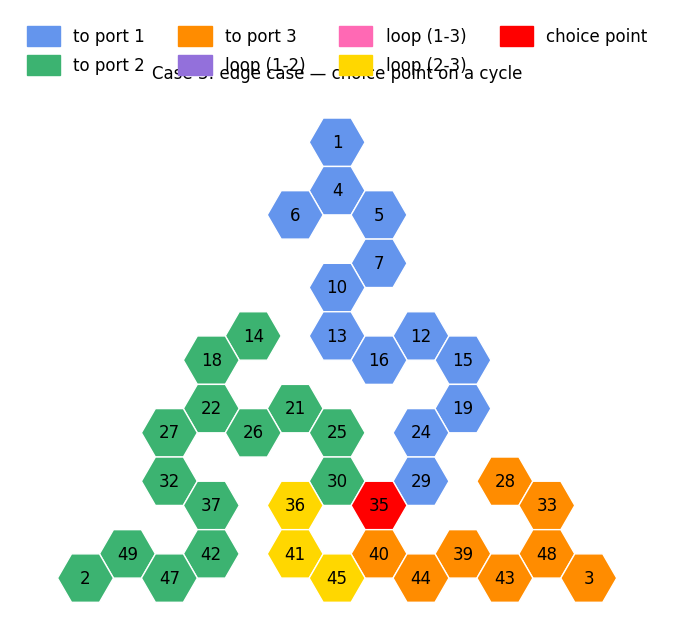

In [3]:
# ── Case 3: edge case — choice point sits on a cycle ─────────────────────────
# When a choice point is on a cycle, removing choice points does not cleanly
# split the graph into 3+ components. classify_hexes_by_region falls back to
# divide_into_thirds (which handles this by excluding the cycle), then assigns
# remaining hexes to their adjacent loop region.
maze_cycle = '8,9,11,17,20,23,31,34,38,46'
regions_cycle = classify_hexes_by_region(maze_cycle)

print("Edge case (CP on cycle) — non-empty regions:")
for k, v in regions_cycle.items():
    if v:
        print(f"  {k}: {sorted(v)}")

sets, colors = region_highlights(regions_cycle)
fig, ax = plt.subplots(figsize=(8, 6))
plot_hex_maze(maze_cycle, highlight_hexes=sets, highlight_colors=colors,
              show_barriers=False, show_hex_labels=True, ax=ax)
ax.set_title("Case 3: edge case — choice point on a cycle")
fig.legend(handles=REGION_LEGEND, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08),
           fontsize=12, handlelength=2, handleheight=1.5, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()

# 2. divide_into_thirds_from_port

In a maze with a choice loop, loop hexes are structurally ambiguous — they don't belong cleanly to any one port's third. `divide_into_thirds_from_port` resolves this from a given start port's perspective: loop segments adjacent to the start port's choice point are assigned to the other port's third. The loop between the two non-start ports (which doesn't touch the start port's choice point) is left unassigned.

The three start ports give three different thirds assignments for the same loop maze. For mazes with no loops, all three give the same result as `divide_into_thirds`.

Start port 1:
  Port 1 third: [1, 4, 5, 6, 7, 9, 12]
  Port 2 third: [2, 11, 13, 14, 17, 18, 21, 22, 26, 31, 32, 36, 38, 41, 42, 46, 47, 49]
  Port 3 third: [3, 19, 23, 28, 33, 39, 43, 44, 48]
Start port 2:
  Port 1 third: [1, 4, 5, 6, 7, 9, 11, 12, 13, 14, 16, 17, 18, 21, 22, 26, 31]
  Port 2 third: [2, 32, 38, 41, 42, 46, 47, 49]
  Port 3 third: [3, 19, 23, 28, 33, 39, 43, 44, 48]
Start port 3:
  Port 1 third: [1, 4, 5, 6, 7, 9, 12, 16]
  Port 2 third: [2, 32, 36, 38, 41, 42, 46, 47, 49]
  Port 3 third: [3, 19, 23, 28, 33, 39, 43, 44, 48]


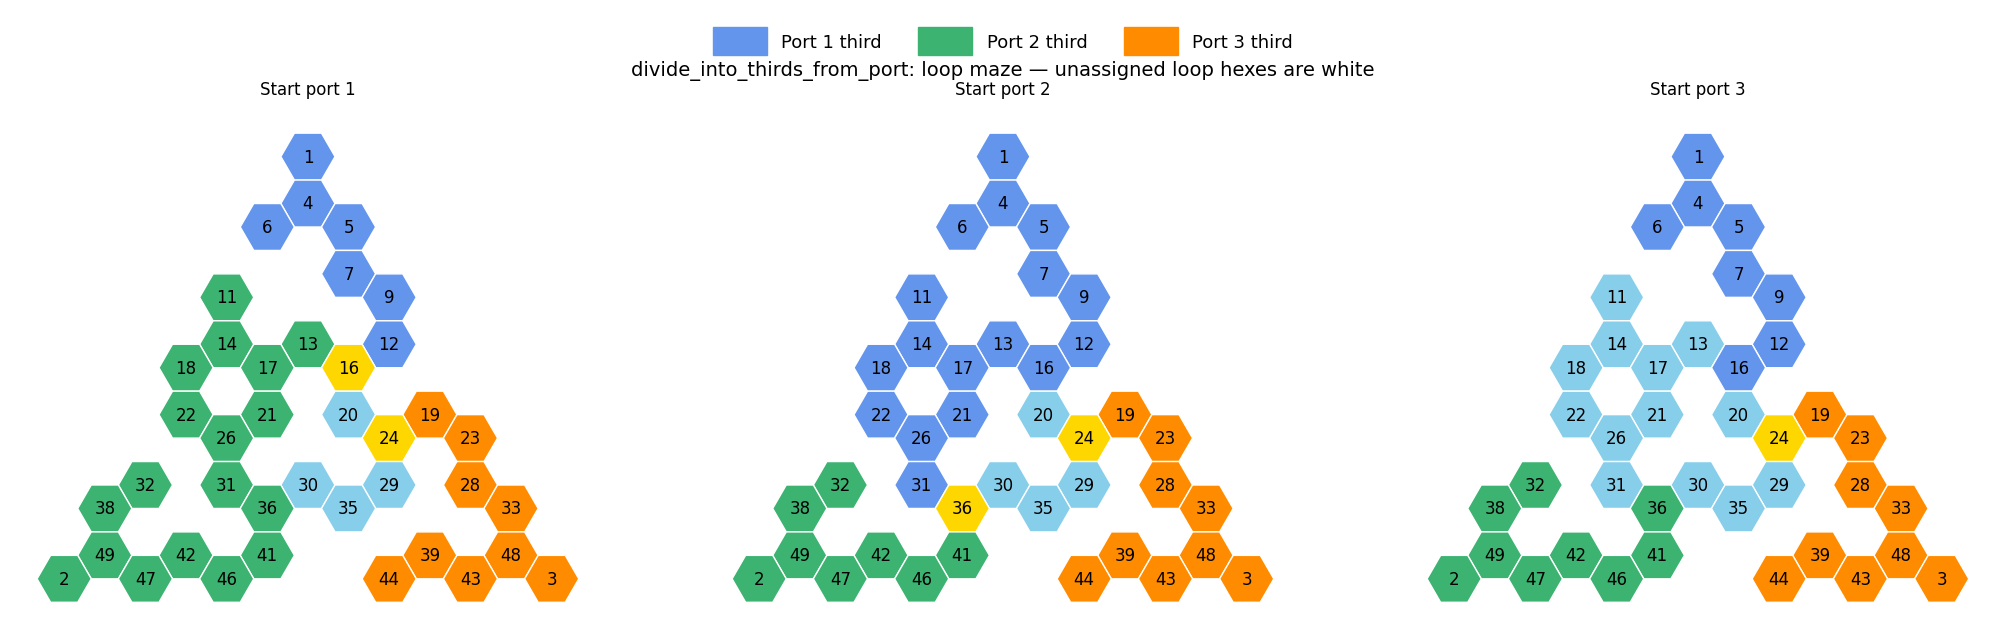

In [4]:
thirds_colors = ['cornflowerblue', 'mediumseagreen', 'darkorange']

thirds_legend = [
    mpatches.Patch(color="cornflowerblue", label="Port 1 third"),
    mpatches.Patch(color="mediumseagreen", label="Port 2 third"),
    mpatches.Patch(color="darkorange",     label="Port 3 third"),
]

# ── Loop maze: compare thirds for each start port ────────────────────────────
maze_loop = '8,10,15,25,27,34,37,40,45'
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, port in enumerate([1, 2, 3]):
    thirds = divide_into_thirds_from_port(maze_loop, start_port=port)
    print(f"Start port {port}:")
    for j, third in enumerate(thirds, 1):
        print(f"  Port {j} third: {sorted(third)}")

    plot_hex_maze(maze_loop, highlight_hexes=thirds, highlight_colors=thirds_colors,
                  show_barriers=False, show_choice_points=True, show_hex_labels=True, ax=axes[i])
    axes[i].set_title(f"Start port {port}")

fig.suptitle("divide_into_thirds_from_port: loop maze — unassigned loop hexes are white", fontsize=14)
fig.legend(handles=thirds_legend, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08),
           fontsize=13, handlelength=3, handleheight=2, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()

Start port 1:
  Port 1 third: [1, 4, 5, 6, 7, 10, 12, 13, 15, 16, 19, 24, 29]
  Port 2 third: [2, 14, 18, 21, 22, 25, 26, 27, 30, 32, 37, 42, 47, 49]
  Port 3 third: [3, 28, 33, 39, 40, 43, 44, 48]
Start port 2:
  Port 1 third: [1, 4, 5, 6, 7, 10, 12, 13, 15, 16, 19, 24, 29]
  Port 2 third: [2, 14, 18, 21, 22, 25, 26, 27, 30, 32, 37, 42, 47, 49]
  Port 3 third: [3, 28, 33, 36, 39, 40, 41, 43, 44, 45, 48]
Start port 3:
  Port 1 third: [1, 4, 5, 6, 7, 10, 12, 13, 15, 16, 19, 24, 29]
  Port 2 third: [2, 14, 18, 21, 22, 25, 26, 27, 30, 32, 36, 37, 41, 42, 45, 47, 49]
  Port 3 third: [3, 28, 33, 39, 40, 43, 44, 48]


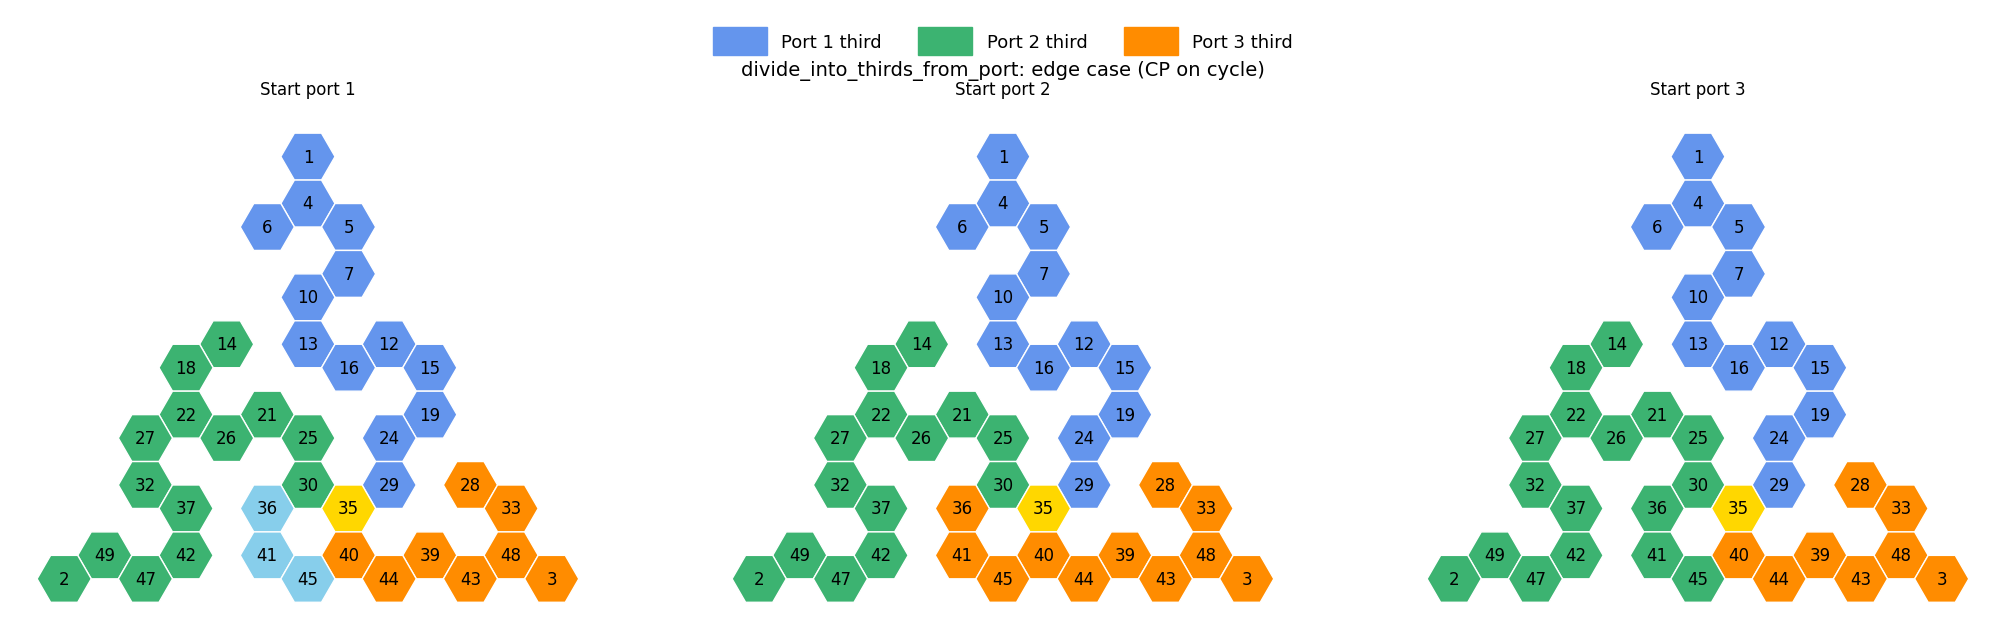

In [5]:
# ── Edge case: CP on cycle ────────────────────────────────────────────────────
maze_cycle = '8,9,11,17,20,23,31,34,38,46'
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, port in enumerate([1, 2, 3]):
    thirds = divide_into_thirds_from_port(maze_cycle, start_port=port)
    print(f"Start port {port}:")
    for j, third in enumerate(thirds, 1):
        print(f"  Port {j} third: {sorted(third)}")

    plot_hex_maze(maze_cycle, highlight_hexes=thirds, highlight_colors=thirds_colors,
                  show_barriers=False, show_choice_points=True, show_hex_labels=True, ax=axes[i])
    axes[i].set_title(f"Start port {port}")

fig.suptitle("divide_into_thirds_from_port: edge case (CP on cycle)", fontsize=14)
fig.legend(handles=thirds_legend, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08),
           fontsize=13, handlelength=3, handleheight=2, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()

# 3. tag_hexes

`tag_hexes` combines two independent classification schemes into a single per-hex tag set. A hex can carry tags from both:
- **Region tags** (`to_port_X`, `choice_loop`): which structural region the hex belongs to, based on `divide_into_thirds`
- **Path role tags** (`optimal`, `non_optimal`, `dead_end`, `choice_point`): the hex's role on maze paths

Below we visualize each scheme separately.

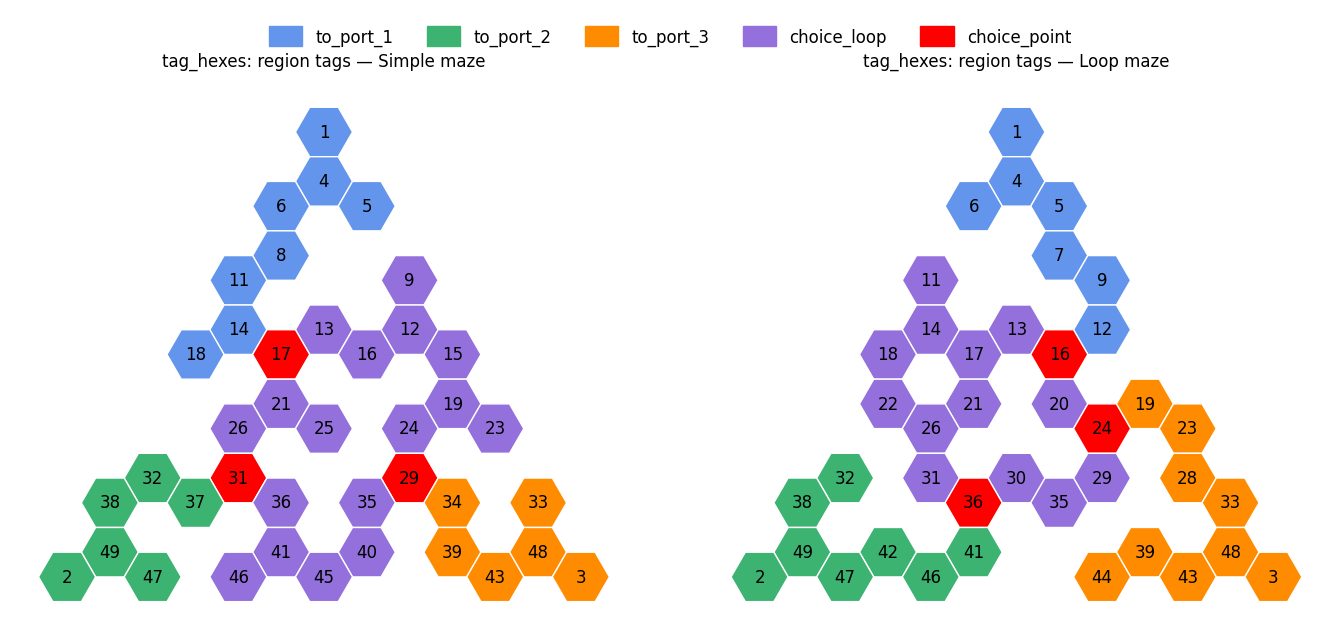

In [6]:
# ── Region tags: to_port_X and choice_loop ────────────────────────────────────
# Simple maze and loop maze side by side
maze_simple = barrier_sequence_database.iloc[7]['barrier_sequence'][0]
maze_loop   = '8,10,15,25,27,34,37,40,45'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, maze, title in zip(axes, [maze_simple, maze_loop], ["Simple maze", "Loop maze"]):
    hex_tags = tag_hexes(maze)

    to_1  = {h for h, tags in hex_tags.items() if "to_port_1"   in tags}
    to_2  = {h for h, tags in hex_tags.items() if "to_port_2"   in tags}
    to_3  = {h for h, tags in hex_tags.items() if "to_port_3"   in tags}
    loop  = {h for h, tags in hex_tags.items() if "choice_loop"  in tags}
    cps   = {h for h, tags in hex_tags.items() if "choice_point" in tags}

    plot_hex_maze(maze, ax=ax,
                  highlight_hexes=[to_1, to_2, to_3, loop, cps],
                  highlight_colors=["cornflowerblue", "mediumseagreen", "darkorange", "mediumpurple", "red"],
                  show_barriers=False, show_hex_labels=True)
    ax.set_title(f"tag_hexes: region tags — {title}")

region_tag_legend = [
    mpatches.Patch(color="cornflowerblue", label="to_port_1"),
    mpatches.Patch(color="mediumseagreen", label="to_port_2"),
    mpatches.Patch(color="darkorange",     label="to_port_3"),
    mpatches.Patch(color="mediumpurple",   label="choice_loop"),
    mpatches.Patch(color="red",            label="choice_point"),
]
fig.legend(handles=region_tag_legend, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.08),
           fontsize=12, handlelength=2, handleheight=1.5, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()


Simple maze:
  Hex  1: ['optimal', 'to_port_1']
  Hex  2: ['optimal', 'to_port_2']
  Hex  3: ['optimal', 'to_port_3']
  Hex  4: ['optimal', 'to_port_1']
  Hex  5: ['dead_end', 'to_port_1']
  Hex  6: ['optimal', 'to_port_1']
  Hex  8: ['optimal', 'to_port_1']
  Hex  9: ['choice_loop', 'dead_end']
  Hex 11: ['optimal', 'to_port_1']
  Hex 12: ['choice_loop', 'optimal']
  Hex 13: ['choice_loop', 'optimal']
  Hex 14: ['optimal', 'to_port_1']
  Hex 15: ['choice_loop', 'optimal']
  Hex 16: ['choice_loop', 'optimal']
  Hex 17: ['choice_loop', 'choice_point', 'choice_point_1', 'optimal']
  Hex 18: ['dead_end', 'to_port_1']
  Hex 19: ['choice_loop', 'optimal']
  Hex 21: ['choice_loop', 'optimal']
  Hex 23: ['choice_loop', 'dead_end']
  Hex 24: ['choice_loop', 'optimal']
  Hex 25: ['choice_loop', 'dead_end']
  Hex 26: ['choice_loop', 'optimal']
  Hex 29: ['choice_loop', 'choice_point', 'choice_point_3', 'optimal']
  Hex 31: ['choice_loop', 'choice_point', 'choice_point_2', 'optimal']
  Hex 32: [

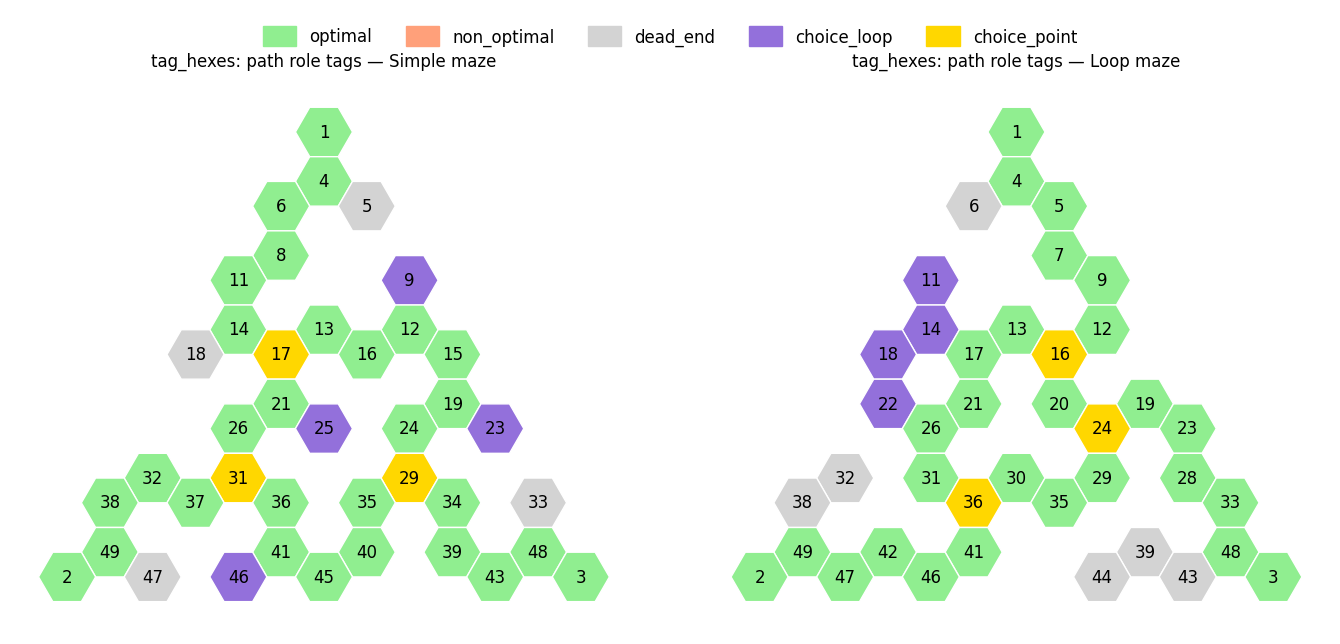

In [7]:
# ── Path role tags: optimal, non_optimal, dead_end, choice_point ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, maze, title in zip(axes, [maze_simple, maze_loop], ["Simple maze", "Loop maze"]):
    hex_tags = tag_hexes(maze)

    optimal     = {h for h, tags in hex_tags.items() if "optimal"     in tags}
    non_optimal = {h for h, tags in hex_tags.items() if "non_optimal" in tags}
    dead_end    = {h for h, tags in hex_tags.items() if "dead_end"    in tags}
    loop_hexes  = {h for h, tags in hex_tags.items() if "choice_loop" in tags}
    cps         = {h for h, tags in hex_tags.items() if "choice_point" in tags}

    # Layer order matters: later sets paint over earlier ones
    plot_hex_maze(maze, ax=ax,
                  highlight_hexes=[dead_end, non_optimal, loop_hexes, optimal, cps],
                  highlight_colors=["lightgray", "lightsalmon", "mediumpurple", "lightgreen", "gold"],
                  show_barriers=False, show_hex_labels=True)
    ax.set_title(f"tag_hexes: path role tags — {title}")

    # Print tags per hex
    print(f"\n{title}:")
    for h in sorted(hex_tags):
        print(f"  Hex {h:2d}: {sorted(hex_tags[h])}")

role_legend = [
    mpatches.Patch(color="lightgreen",   label="optimal"),
    mpatches.Patch(color="lightsalmon",  label="non_optimal"),
    mpatches.Patch(color="lightgray",    label="dead_end"),
    mpatches.Patch(color="mediumpurple", label="choice_loop"),
    mpatches.Patch(color="gold",         label="choice_point"),
]
fig.legend(handles=role_legend, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.08),
           fontsize=12, handlelength=2, handleheight=1.5, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()

# 4. get_junction_left_right_map

For every 3-way junction (a hex with exactly 3 open neighbors) and every possible entry direction, `get_junction_left_right_map` classifies the two exits as `'left'` or `'right'` relative to the rat's heading. The heading vector is entry → junction, and the exit vector is junction → exit; the sign of their 2D cross product determines turn direction.

Note: this function is not yet exported from the top-level `src.hexmaze` package — import it from `src.hexmaze.core`.

In [8]:
from src.hexmaze.core import get_junction_left_right_map

maze = barrier_sequence_database.iloc[7]['barrier_sequence'][0]
lr_map = get_junction_left_right_map(maze)

print("Junction left/right map (junction, entry) → exits:")
for (junc, entry), exits in sorted(lr_map.items()):
    print(f"  junction={junc:2d}, entry from {entry:2d}:  left={exits['left']:2d},  right={exits['right']:2d}")

Junction left/right map (junction, entry) → exits:
  junction= 4, entry from  1:  left= 5,  right= 6
  junction= 4, entry from  5:  left= 6,  right= 1
  junction= 4, entry from  6:  left= 1,  right= 5
  junction=12, entry from  9:  left=15,  right=16
  junction=12, entry from 15:  left=16,  right= 9
  junction=12, entry from 16:  left= 9,  right=15
  junction=14, entry from 11:  left=17,  right=18
  junction=14, entry from 17:  left=18,  right=11
  junction=14, entry from 18:  left=11,  right=17
  junction=17, entry from 13:  left=21,  right=14
  junction=17, entry from 14:  left=13,  right=21
  junction=17, entry from 21:  left=14,  right=13
  junction=19, entry from 15:  left=23,  right=24
  junction=19, entry from 23:  left=24,  right=15
  junction=19, entry from 24:  left=15,  right=23
  junction=21, entry from 17:  left=25,  right=26
  junction=21, entry from 25:  left=26,  right=17
  junction=21, entry from 26:  left=17,  right=25
  junction=29, entry from 24:  left=34,  right=35

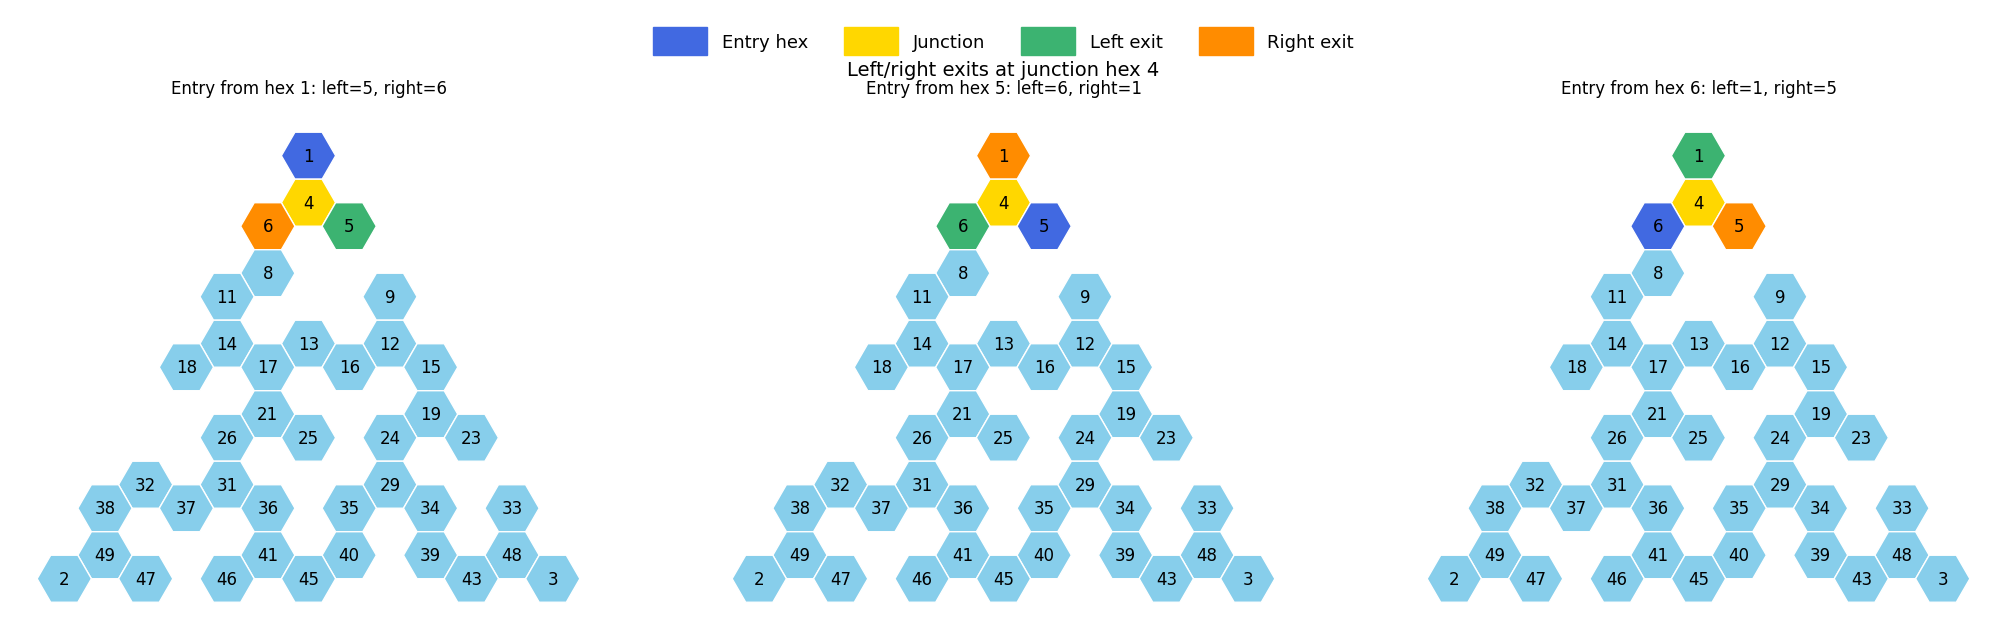

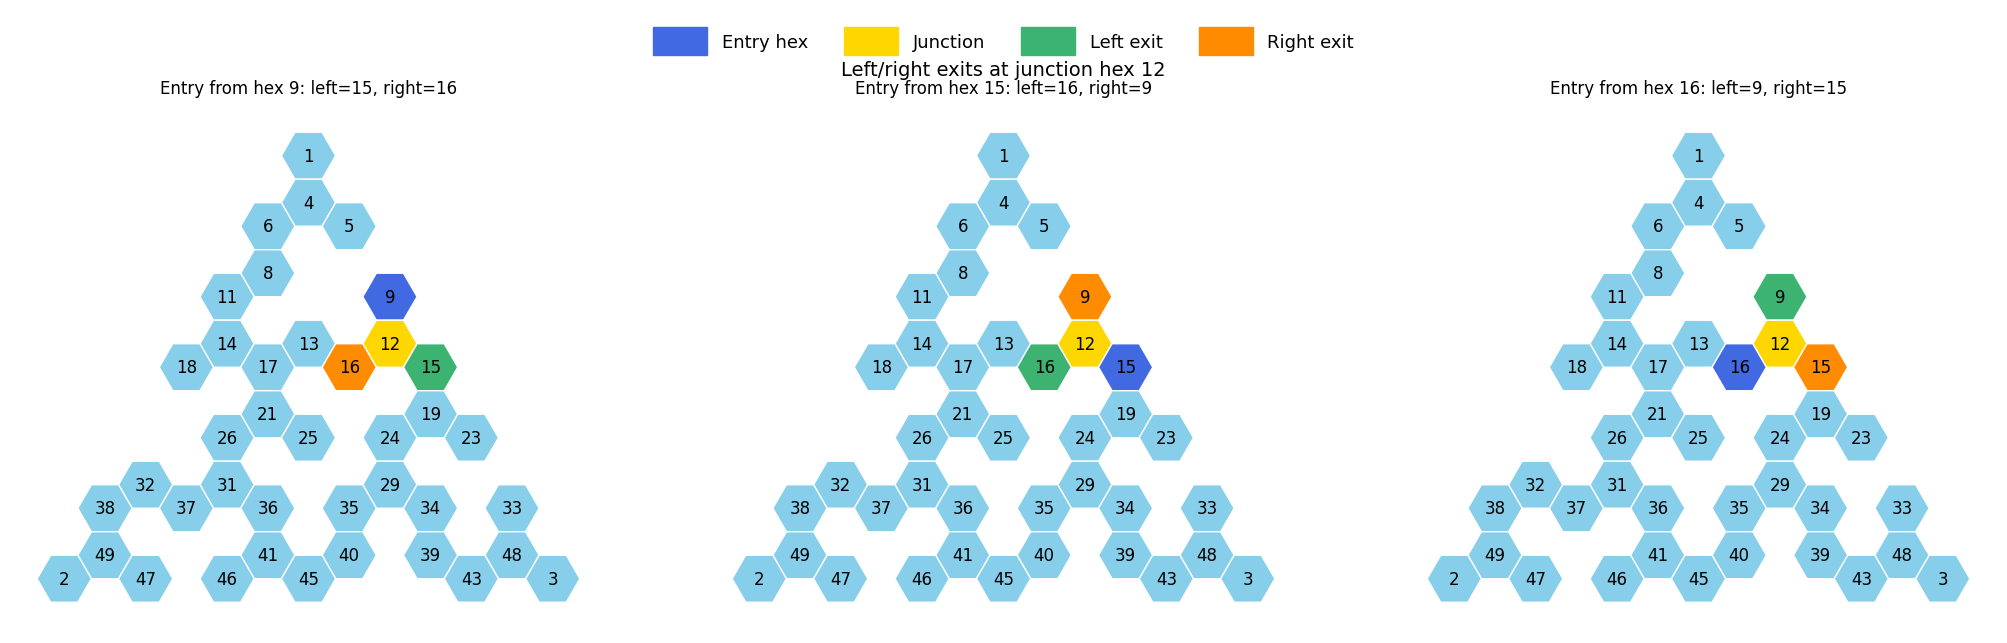

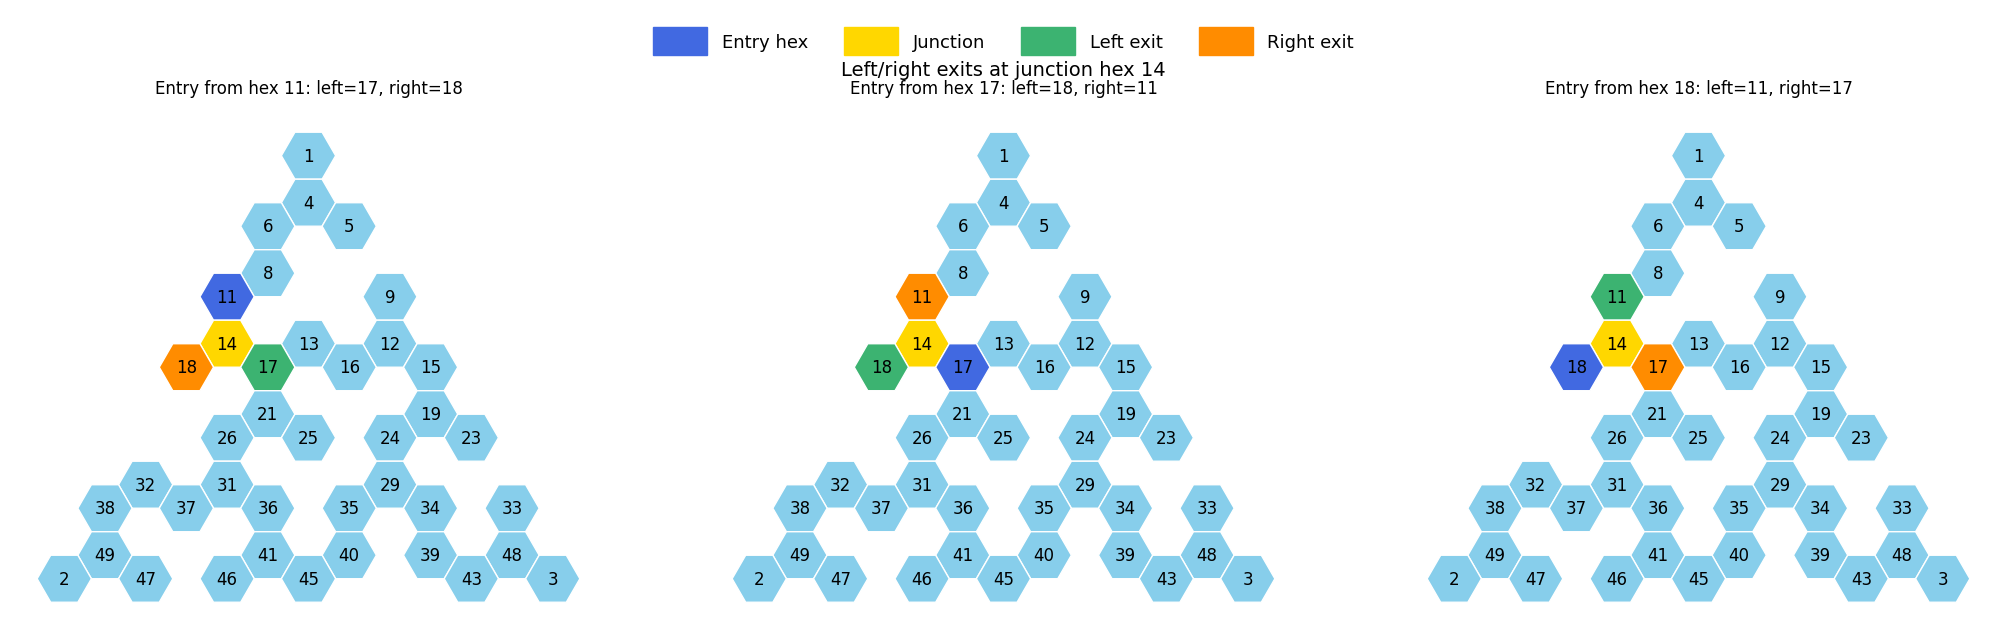

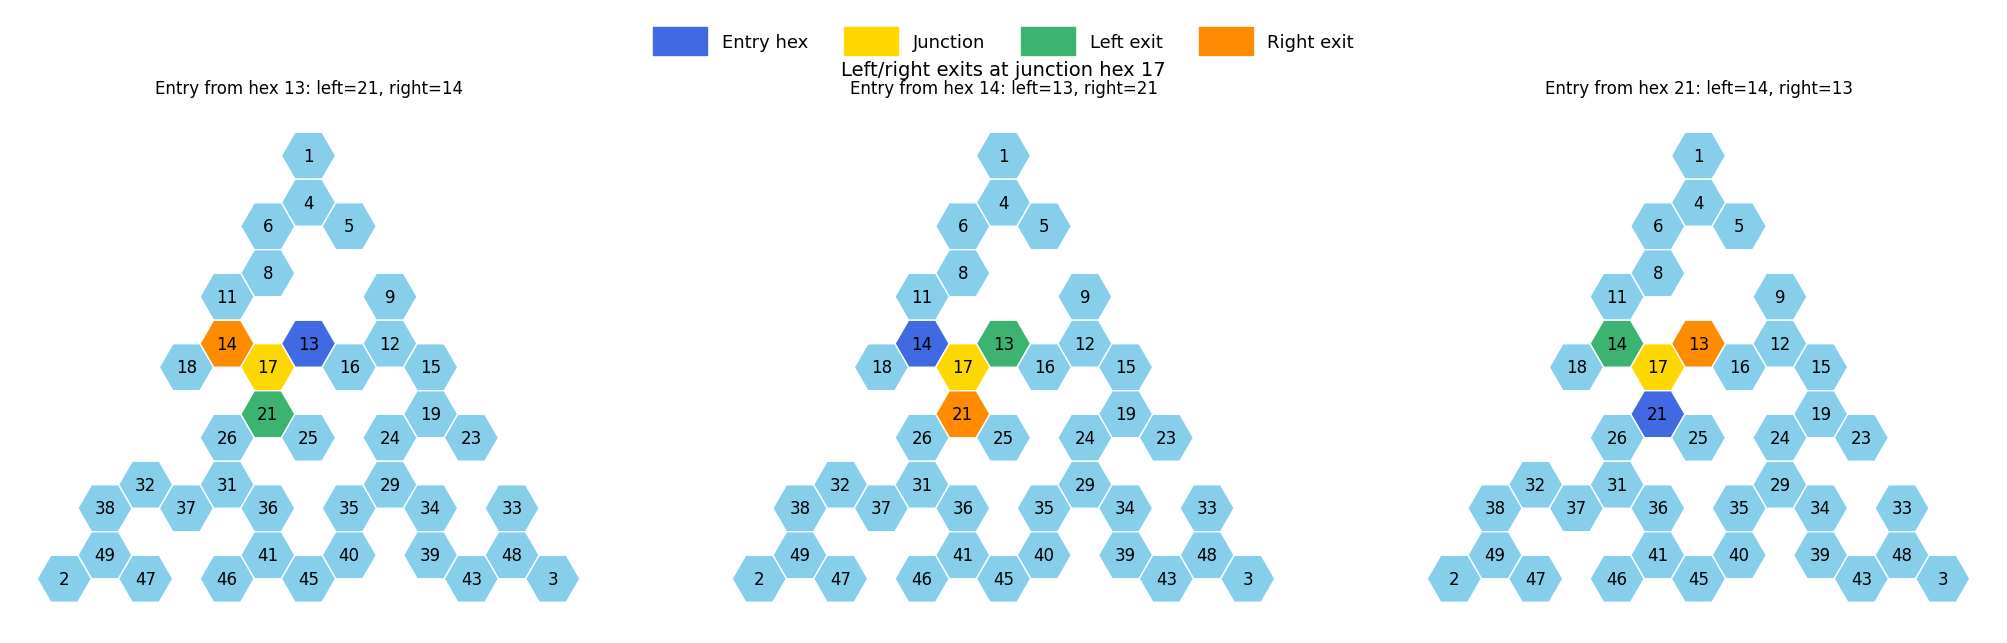

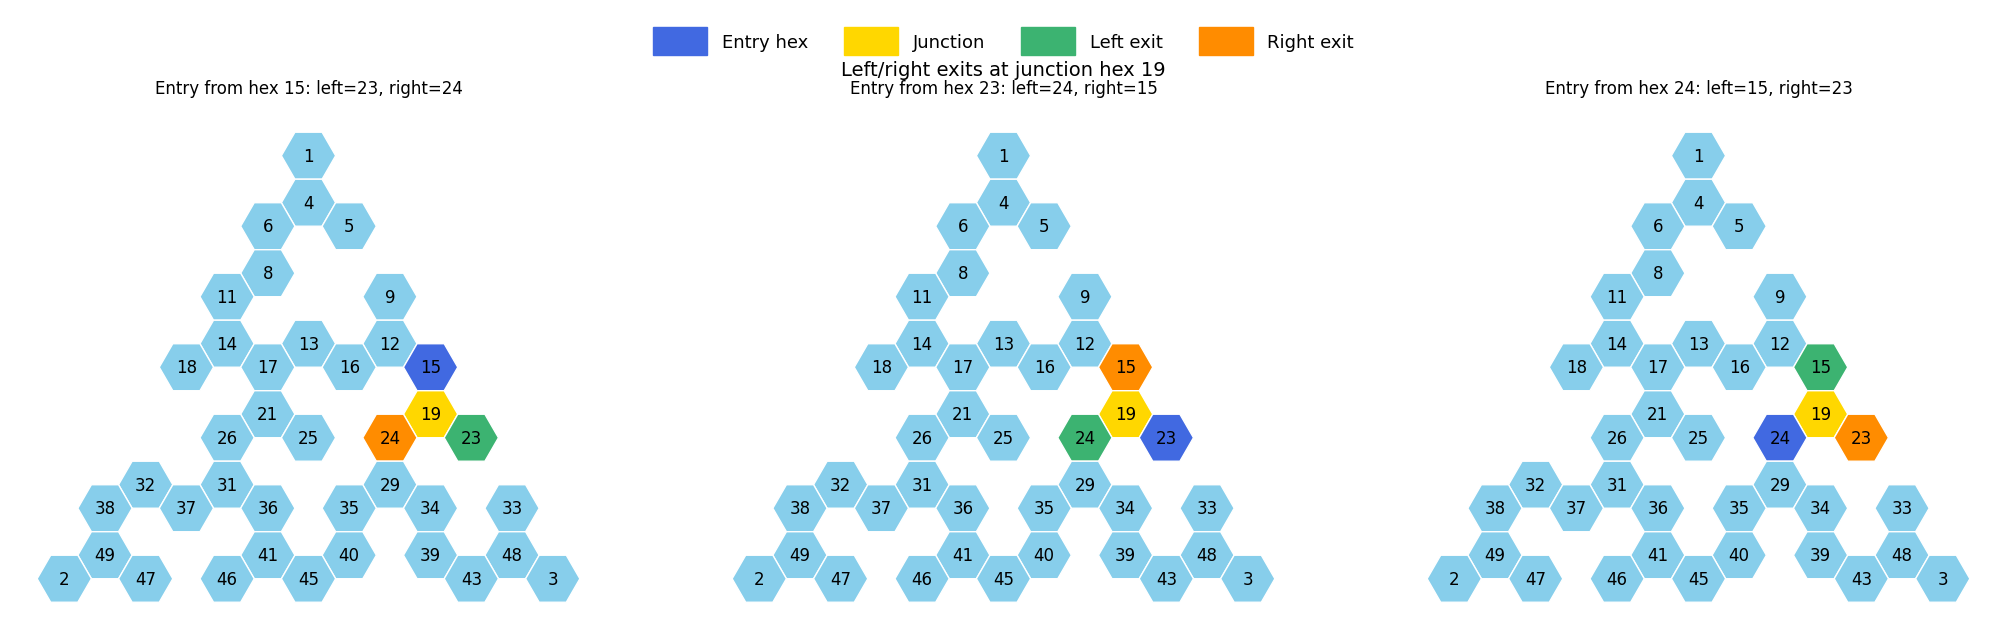

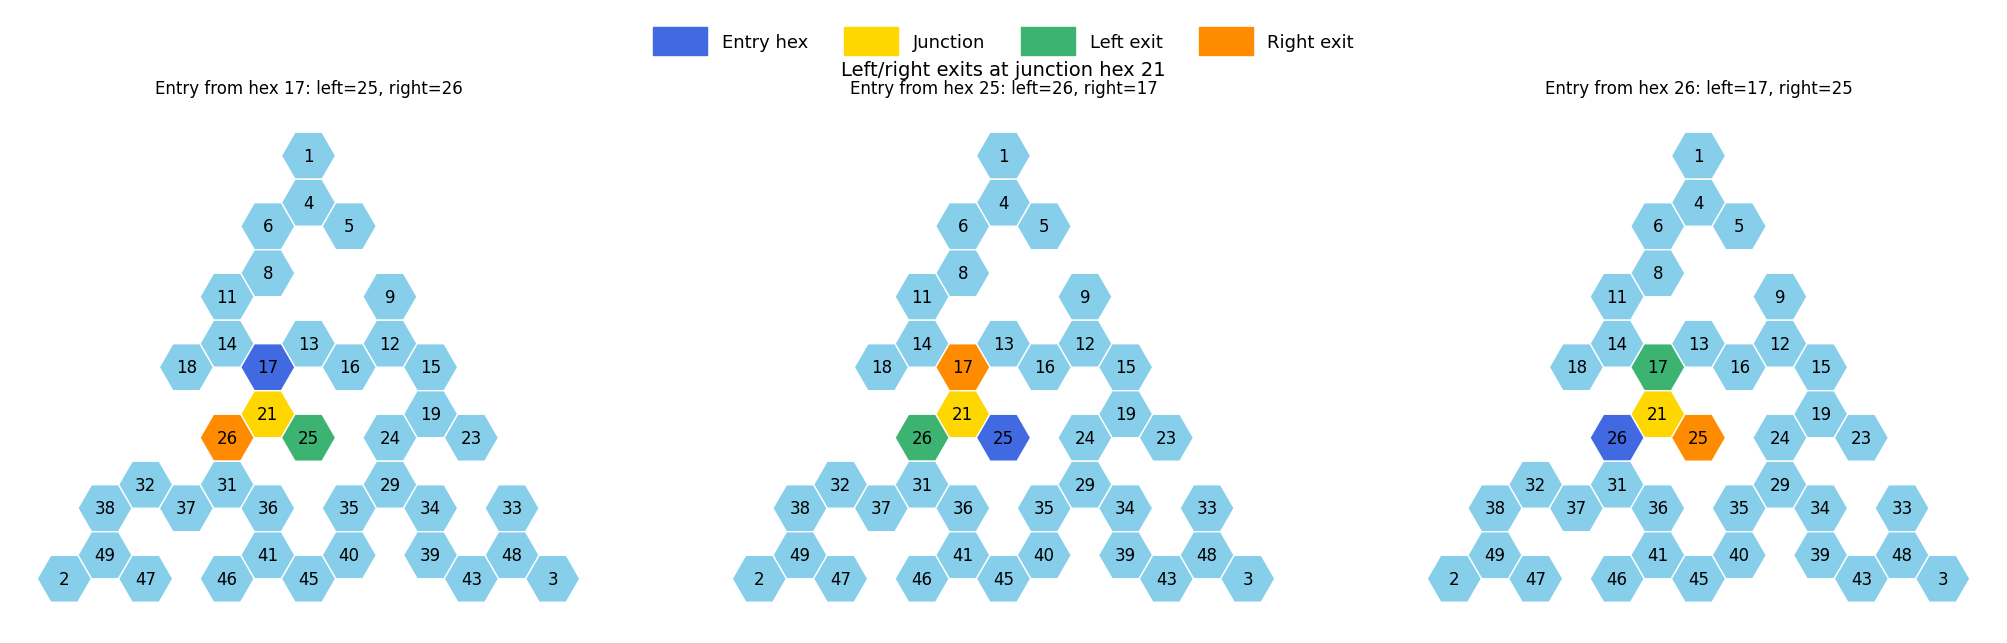

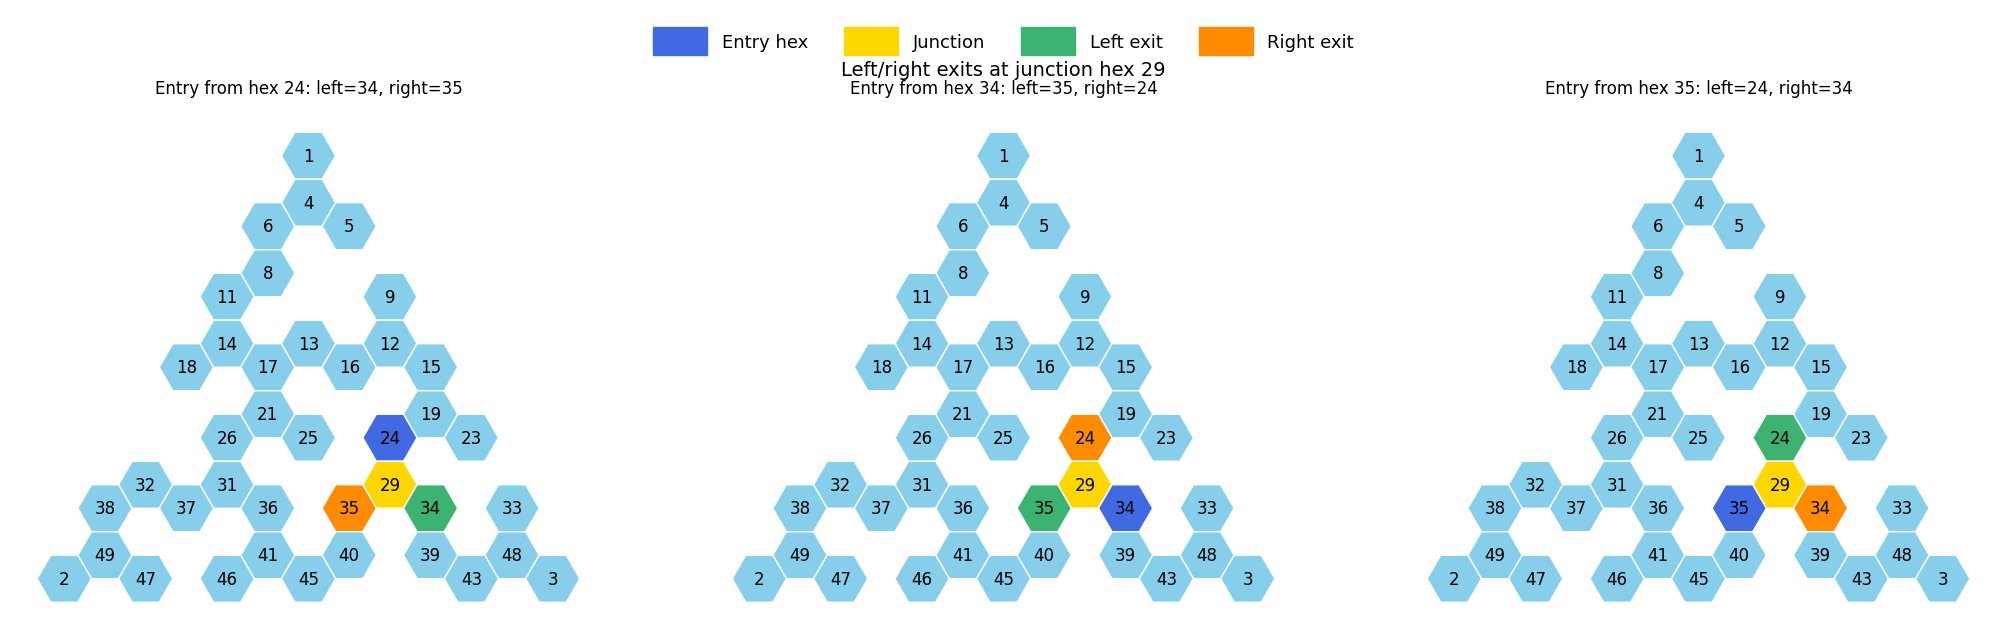

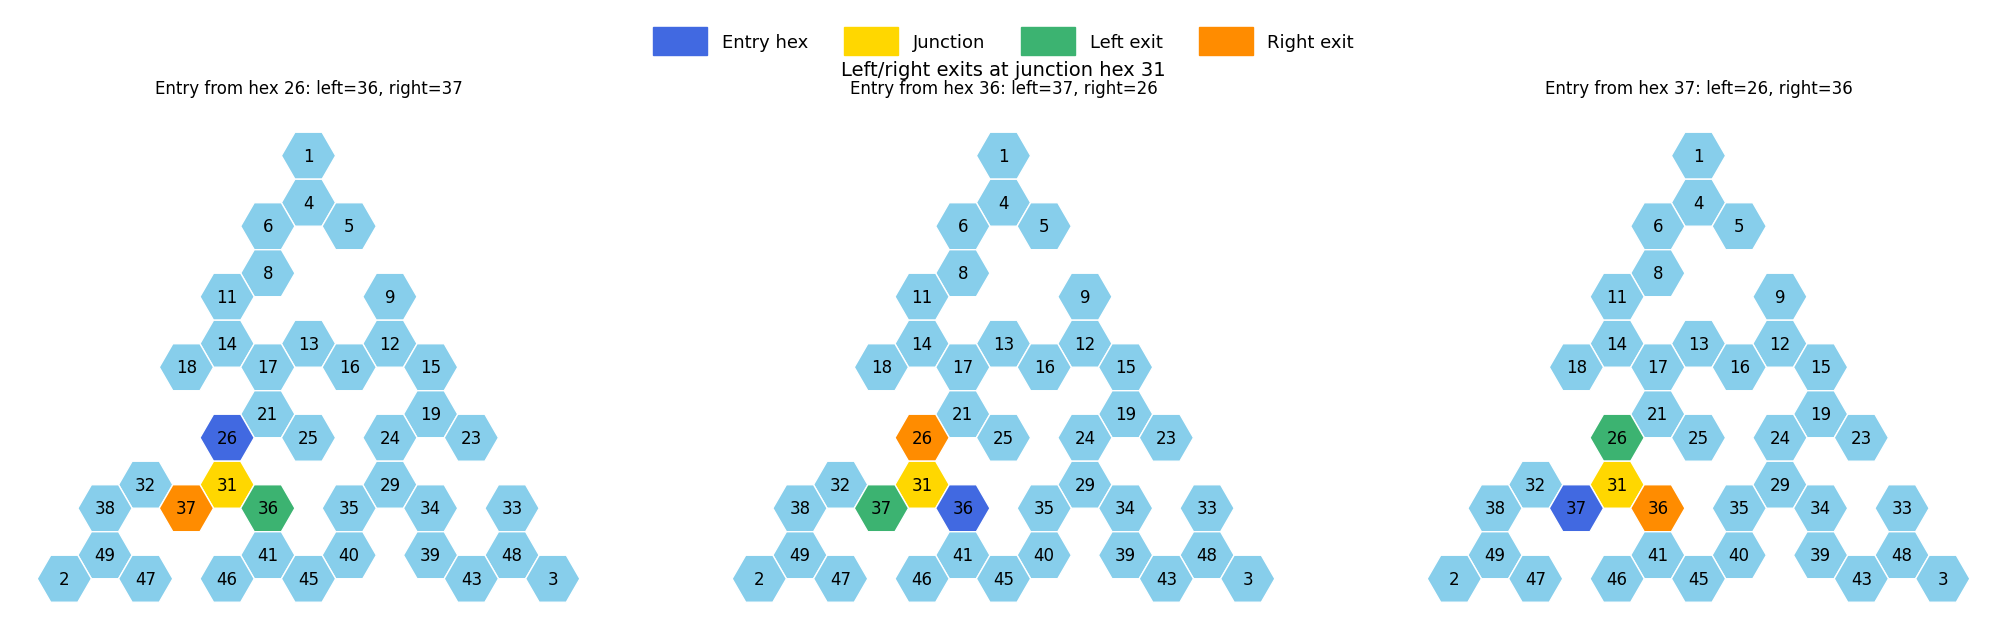

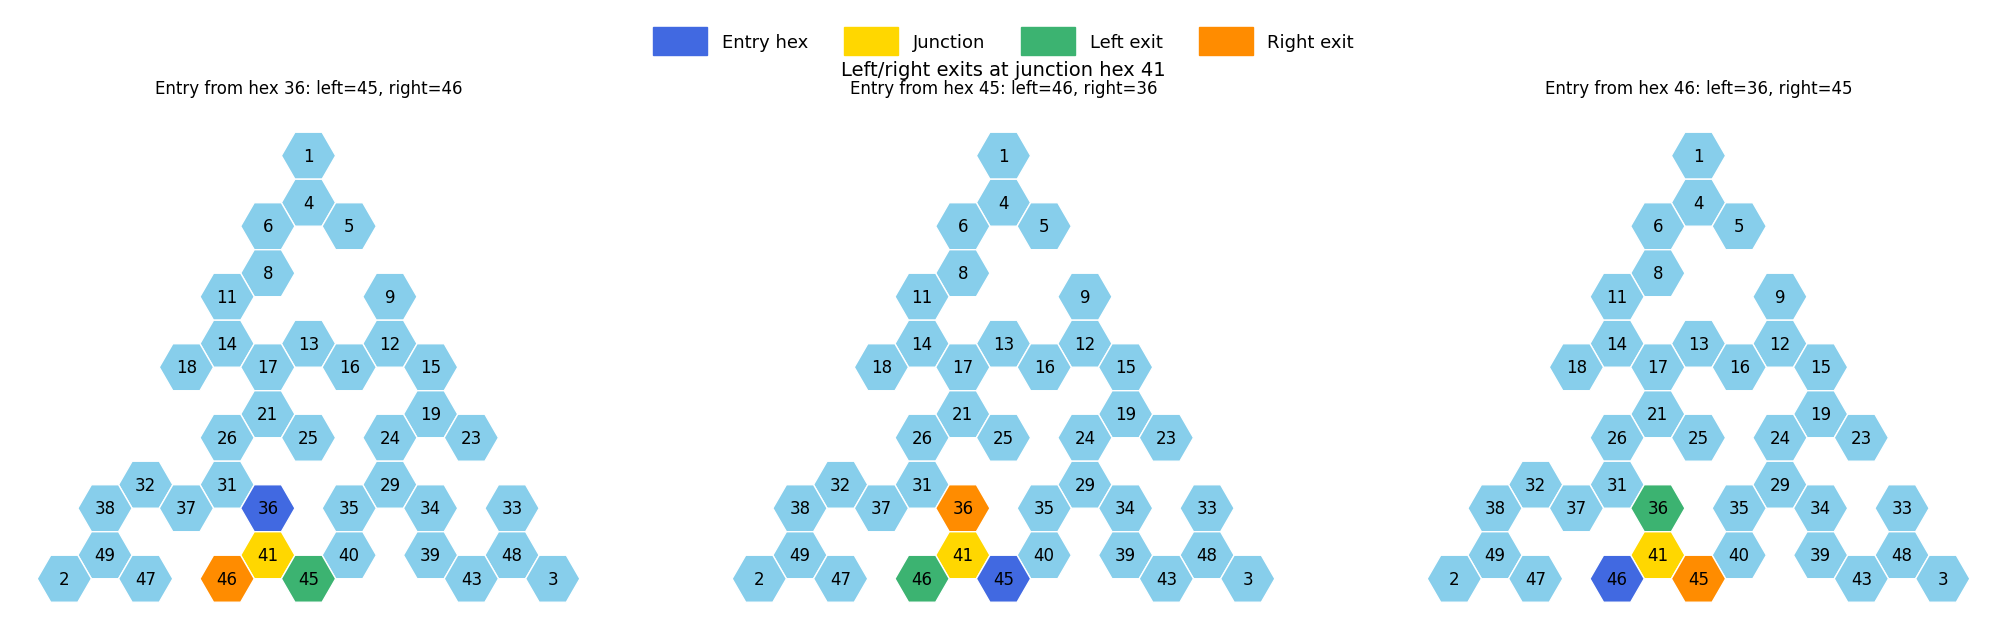

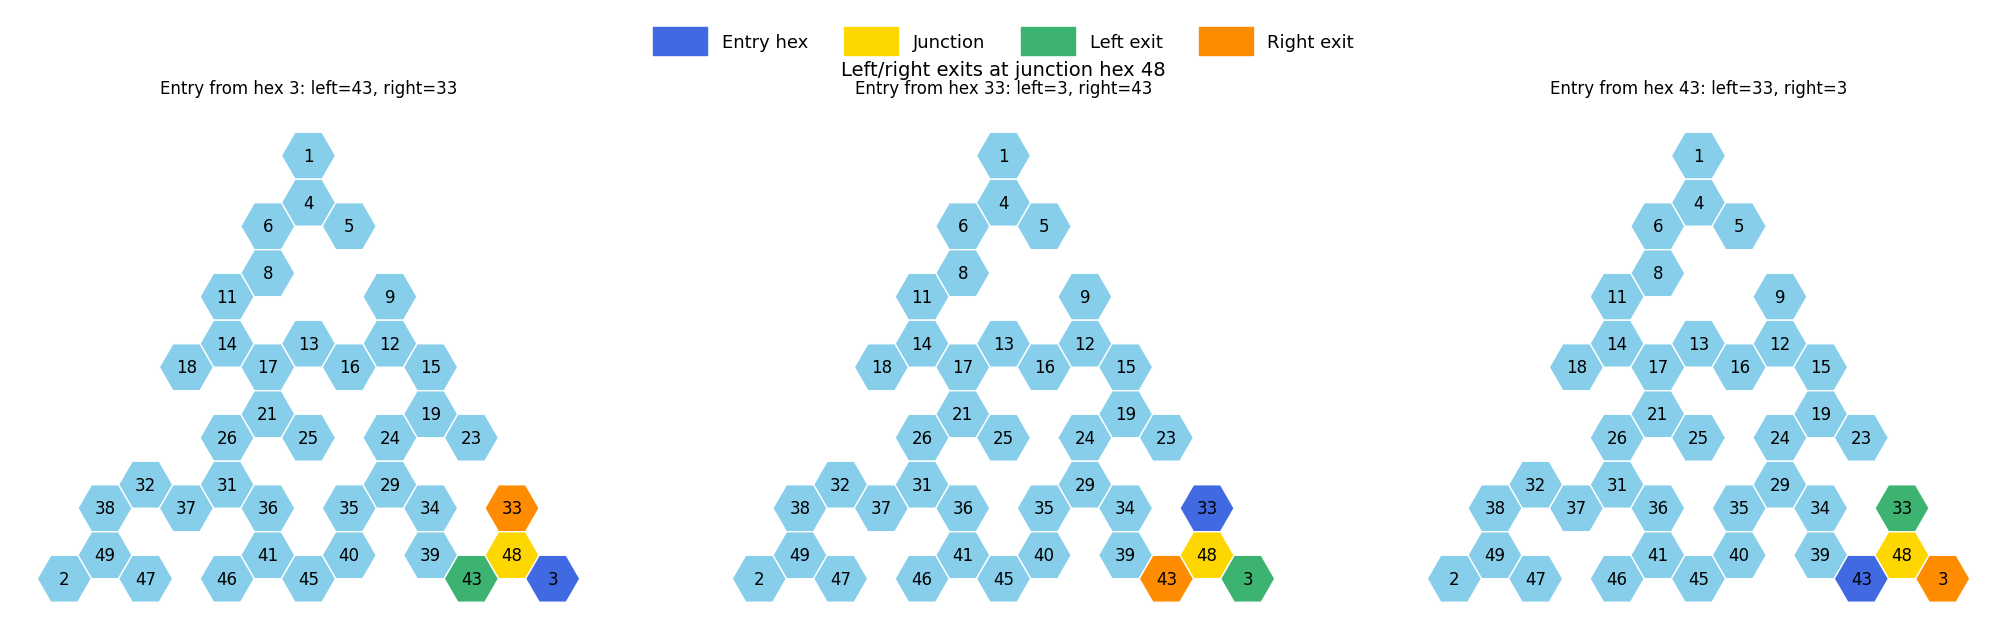

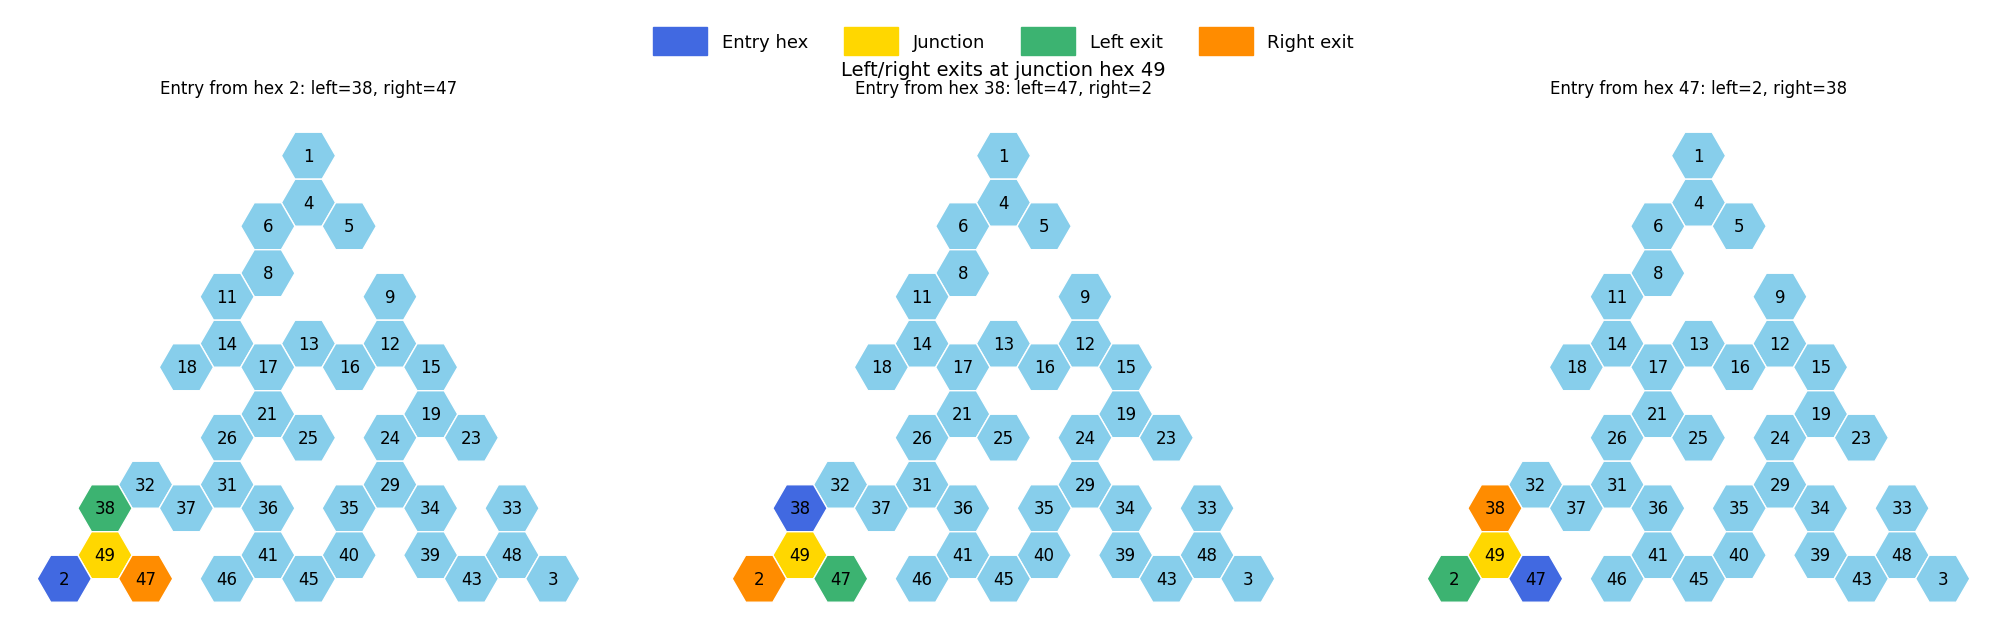

In [9]:
# Visualize left/right exits for each entry direction at every junction
maze = barrier_sequence_database.iloc[7]['barrier_sequence'][0]
lr_map = get_junction_left_right_map(maze)

junction_hexes = sorted(get_all_choice_points(maze))

for junc in junction_hexes:
    entries = sorted(entry for (j, entry) in lr_map if j == junc)
    fig, axes = plt.subplots(1, len(entries), figsize=(7 * len(entries), 6))
    if len(entries) == 1:
        axes = [axes]

    for ax, entry in zip(axes, entries):
        left_exit  = lr_map[(junc, entry)]['left']
        right_exit = lr_map[(junc, entry)]['right']

        plot_hex_maze(maze, ax=ax,
                      highlight_hexes=[{entry}, {junc}, {left_exit}, {right_exit}],
                      highlight_colors=["royalblue", "gold", "mediumseagreen", "darkorange"],
                      show_barriers=False, show_hex_labels=True)
        ax.set_title(f"Entry from hex {entry}: left={left_exit}, right={right_exit}")

    lr_legend = [
        mpatches.Patch(color="royalblue",     label="Entry hex"),
        mpatches.Patch(color="gold",          label="Junction"),
        mpatches.Patch(color="mediumseagreen",label="Left exit"),
        mpatches.Patch(color="darkorange",    label="Right exit"),
    ]
    fig.suptitle(f"Left/right exits at junction hex {junc}", fontsize=14)
    fig.legend(handles=lr_legend, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08),
               fontsize=13, handlelength=3, handleheight=2, borderpad=1, frameon=False)
    plt.tight_layout()
    plt.show()